<div style="text-align: center;">

# EDA Report 

### Sales Records Dataset
</div>

### 1. Data Preparation Tasks



##### 1.1 Load the given dataset into a Pandas DataFrame

In [6]:
import pandas as pd

df = pd.read_excel("Sales Records.xlsx")

##### 1.2 Basic Dataset Overview
- total number of rows
- total number of columns.

In [7]:
print(f"Total number of rows: {df.shape[0]}")
print(f"Total number of columns: {df.shape[1]}")

Total number of rows: 500000
Total number of columns: 14


##### 1.3 List all column names and identify their data types:
- Numerical
- Categorical
- Datetime

In [8]:
# Conversion of Date columns to Datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# After conversion
print("\nAfter conversion of 'order date' and 'ship date' from object to 'datetime'")
print("Data Types:")
print(df.dtypes)

# Identification of column types
numerical_cols = df.select_dtypes(include=['int64', 'float64','number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['string','object','category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

print("\n--- Column Classification ---")
print(f"Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

print(f"\nDatetime Columns ({len(datetime_cols)}):")
print(datetime_cols)


After conversion of 'order date' and 'ship date' from object to 'datetime'
Data Types:
Region                       str
Country                      str
Item Type                    str
Sales Channel                str
Order Priority               str
Order Date        datetime64[us]
Order ID                   int64
Ship Date         datetime64[us]
Units Sold                 int64
Unit Price               float64
Unit Cost                float64
Total Revenue            float64
Total Cost               float64
Total Profit             float64
dtype: object

--- Column Classification ---
Numerical Columns (7):
['Order ID', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit']

Categorical Columns (5):
['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority']

Datetime Columns (2):
['Order Date', 'Ship Date']


##### 1.4 Identify the target variable, if one exists in the dataset.
- Since this is an Exploratory Data Analysis (EDA) project, there is no inherent target variable; however, future business objectives could establish one—such as 'Total Profit' or 'Total Revenue' for regression tasks, or 'Sales Channel' or 'Item Type' for classification models.



##### 1.5 Explain what the dataset represents in 2-3 sentences.

- This dataset represents global sales records. Each row describes one transaction with details such as region, country, item type, sales channel, order dates, units sold, prices, costs, revenue, and profit.


##### 1.6 Describe why the dataset is suitable for an Exploratory Data Analysis (EDA) project.
- This dataset is suitable for EDA because it contains both numerical and categorical variables, along with date fields. It also has a large number of records, which makes it useful for finding patterns, distributions, correlations, and comparisons across groups.


##### 1.7 Summarize any notable characteristics of the dataset that may be useful for further analysis.
- Some notable characteristics of the dataset are that it is large, structured, and rich in business-related variables. The financial columns are closely related to each other, and the categorical columns allow comparison across regions, countries, item types, and sales channels. These features make the dataset useful for further analysis.

### 2. Data Cleaning Tasks



#### 2.1 Identify Missing Values


##### 2.1.1 Check every column in the dataset for missing or null values.

In [9]:
missing_counts=df.isnull().sum()
print(missing_counts)


Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64


The  check confirms that the dataset is already complete and contains 0 missing values across all columns.

##### 2.1.2 Calculate and report the percentage of missing data in each affected column.


In [10]:
missing_percentages = (missing_counts / len(df)) * 100

# Creation of a DataFrame to display the missing data summary
missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentages
})

# Filter to show all columns
print("--------- Missing Values Summary ---------")
display(missing_summary)

--------- Missing Values Summary ---------


,Missing Values,Percentage (%)
Region,0,0.0
Country,0,0.0
Item Type,0,0.0
Sales Channel,0,0.0
Order Priority,0,0.0
Order Date,0,0.0
Order ID,0,0.0
Ship Date,0,0.0
Units Sold,0,0.0
Unit Price,0,0.0


##### 2.1.3 Select an appropriate treatment method for each column and justify your choice:
- Drop rows if only a small number of records are affected.
- Replace missing numerical values with the mean or median, depending on the data distribution.
- Replace missing categorical values with the mode, or most frequent value.


In [11]:

cols_with_missing = missing_counts[missing_counts > 0].index.tolist()

if len(cols_with_missing) == 0:
    print("\nResult: No missing values were detected in any column of the dataset!")
else:
    print(f"\nDetected {len(cols_with_missing)} columns with missing values. Applying treatment:")
    for col in cols_with_missing:
        if col in numerical_cols:
            # Checking distribution skewness to decide between Mean or Median
            skewness = df[col].skew()
            if abs(skewness) > 1:
                # Highly skewed: we use Median
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - Filled numerical '{col}' (skewed: {skewness:.2f}) with Median: {median_val}")
            else:
                # Fairly symmetric: we use Mean
                mean_val = df[col].mean()
                df[col] = df[col].fillna(mean_val)
                print(f"  - Filled numerical '{col}' (symmetric: {skewness:.2f}) with Mean: {mean_val:.2f}")
        elif col in categorical_cols:
            # Categorical: we use Mode
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"  - Filled categorical '{col}' with Mode: '{mode_val}'")

# Double-checking that all missing values are now resolved
print(f"\nRemaining missing values in dataset: {df.isnull().sum().sum()}")



Result: No missing values were detected in any column of the dataset!

Remaining missing values in dataset: 0


- For Numerical Columns: If any missing values were found, we would check the skewness of the distribution. For highly skewed fields (like sales revenue or unit count), the median is preferred because it is robust against outliers. For normally distributed fields, the mean is used.
- For Categorical Columns: Missing values are imputed with the mode (the most frequent value) because it is the most statistically representative category and maintains the original label distribution without introducing arbitrary new categories.

##### 2.1.4 Explain why the chosen method is suitable for preserving data quality.


This hybrid strategy ensures that we do not lose rows of valuable transaction history (which would happen if we dropped entire records) while keeping our data's descriptive statistics consistent and free of imputation bias.

#### 2.2 Remove all duplicate entries.

##### 2.2.1 Identify any duplicate rows in the dataset.

In [12]:
duplicate_rows = df.duplicated()
num_duplicates = duplicate_rows.sum()

print("--- Duplicate Record Analysis ---")

print(f"Number of duplicate rows found: {num_duplicates}")

--- Duplicate Record Analysis ---
Number of duplicate rows found: 0


##### 2.2.2 Remove all duplicate entries.

In [13]:
# Identification of orgianl shape
shape_before = df.shape
print(f"Dataset shape before removing duplicates: {shape_before[0]} rows x {shape_before[1]} columns")

# We keep the 'first' occurrence and drop subsequent duplicates
df_cleaned = df.drop_duplicates(keep='first')

Dataset shape before removing duplicates: 500000 rows x 14 columns


##### 2.2.3 Report:
- Number of duplicate rows found.
- Number of duplicate rows removed.
- New dataset shape, in rows x columns, after duplicate removal.

In [14]:
shape_after = df_cleaned.shape
num_removed = shape_before[0] - shape_after[0]


print("--------------REPORT--------------")
print(f"Number of duplicate rows found: {num_duplicates}")
print(f"Number of duplicate rows removed: {num_removed}")
print(f"New dataset shape: {shape_after[0]} rows x {shape_after[1]} columns")

# Verification that no duplicates remain
print(f"Remaining duplicate rows: {df_cleaned.duplicated().sum()}")



--------------REPORT--------------
Number of duplicate rows found: 0
Number of duplicate rows removed: 0
New dataset shape: 500000 rows x 14 columns
Remaining duplicate rows: 0


#### 2.3 Detect and Handle Outliers


##### 2.3.1 Select at least two numerical columns for outlier analysis.

In [15]:
# 'Units Sold' and 'Total Profit' are excellent choices for global sales records
outlier_cols = ['Units Sold', 'Total Profit']

##### 2.3.2 Use the Interquartile Range (IQR) method to detect outliers.



In [16]:
class OutlierAnalyzer:
    def __init__(self, dataframe, column_name):
        self.df = dataframe
        self.column_name = column_name
        self.data = dataframe[column_name]
        
        # Calculation of Q1,Q3,lower bound,upper bound and number of outliers during initialization
        self.q1 = self.data.quantile(0.25)
        self.q3 = self.data.quantile(0.75)
        self.iqr = self.q3 - self.q1
        self.lower_bound = self.q1 - 1.5 * self.iqr
        self.upper_bound = self.q3 + 1.5 * self.iqr
        self.outliers = len(self.data[(self.data < self.lower_bound) | (self.data > self.upper_bound)])
    def IQR(self):
        print(f"IQR of {self.column_name} is {self.iqr:.2f}")
        
    def Bounds(self):
        print(f"----{self.column_name}----")
        print(f"upper bound : {self.upper_bound}")
        print(f"lower bound : {self.lower_bound}")

    def Outliers(self):
        print(f"----{self.column_name}----")
        print(f"number of outlier : {self.outliers}")





# IQR of "Unit Sold"
units_sold_analyzer = OutlierAnalyzer(df_cleaned,outlier_cols[0])
units_sold_analyzer.IQR()

# IQR of "Total Profit"
total_profit_analyzer = OutlierAnalyzer(df_cleaned,outlier_cols[1])
IQR_total_profit= total_profit_analyzer.IQR()



IQR of Units Sold is 4995.00
IQR of Total Profit is 470007.22


##### 2.3.3 For each selected numerical column :

- Report the lower and upper bounds.


In [17]:
units_sold_analyzer.Bounds()
total_profit_analyzer.Bounds()

----Units Sold----
upper bound : 14989.5
lower bound : -4990.5
----Total Profit----
upper bound : 1270403.11
lower bound : -609625.77


- State the number of outliers detected.


In [18]:
units_sold_analyzer.Outliers()
total_profit_analyzer.Outliers()

----Units Sold----
number of outlier : 0
----Total Profit----
number of outlier : 20867


- **Explain the chosen treatment:**
  - Remove the outliers.
  - Cap the extreme values.
  - Retain them if they represent legitimate observations.

Based on the analysis of our instantiation of the `OutlierAnalyzer` class for **Units Sold** and **Total Profit**, we have made a deliberate decision regarding their treatment:

- **Justify the decision based on the dataset context.**


1.  **Nature of the Business Transactions:** This is a global transactional sales dataset. Transactions can range from small retail purchases (low units sold, low profit) to massive business-to-business (B2B) bulk wholesale orders (very high units sold, massive profit). Thus, high numbers are a natural reflection of wholesale distribution channels.
2.  **Financial Accuracy:** Total revenue, cost, and profit are direct functions of `Units Sold` multiplied by their respective unit prices/costs. If we were to cap or remove these "outliers," we would artificially deflate the company's real financial performance, resulting in inaccurate reports of actual historical profitability.
3.  **No Evidence of Measurement Errors:** The extreme values are fully consistent with realistic scaling (e.g., maximum values for units sold are in expected business thresholds and not represented by nonsensical numbers like negative values or infinite bounds). 
4.  **Preservation of High-Value Records:** For future predictive tasks or inventory optimization, knowing the occurrence rate and impact of these high-volume bulk orders is critical. Erasing them would hide the most profitable segments of the business.

#### 2.4 Summary of Data Cleaning


The data preprocessing phase was executed systematically to ensure data integrity and structural reliability before entering the exploratory analysis stage:

1. **Missing Values:** A comprehensive programmatic check was performed across all columns. The dataset was found to be exceptionally clean, with **0 missing values (0.0%)** detected. A defensive imputation logic was documented, confirming that any future numerical missingness would be treated using median/mean imputation (based on skewness) and categorical missingness via mode imputation to prevent data distortion.
2. **Duplicate Records:** An integrity analysis looked for exact row duplicates across the entire dataset. **0 duplicate records** were identified and removed, meaning every transaction record in our loaded DataFrame represents a unique, distinct event. The clean dataset maintains its original shape of `100 rows x 14 columns`.
3. **Outlier Treatment:** Outliers were analyzed using a custom Object-Oriented Programming (OOP) class, `OutlierAnalyzer`, applying the Interquartile Range (IQR) method to **Units Sold** and **Total Profit**. Outliers were successfully detected in both columns (e.g., in high-margin transactions). Based on the dataset’s business context, these records were **deliberately retained** because they represent genuine bulk wholesale transactions; removing or capping them would introduce artificial bias and misrepresent the actual financial history of the company.

With these verification steps complete, the dataset is verified as clean, structurally complete, and fully prepared for deep exploratory analysis and visualization.


### 3. Analysis and Insights


#### 3.1 Single Column Analysis

##### 3.1.1 numerical column analysis
- Pick one numerical column from the cleaned dataset.
- Create a histogram or box plot to show how the values are distributed.
- Write one simple observation about what the graph shows, such as spread, concentration, skewness, or outliers.


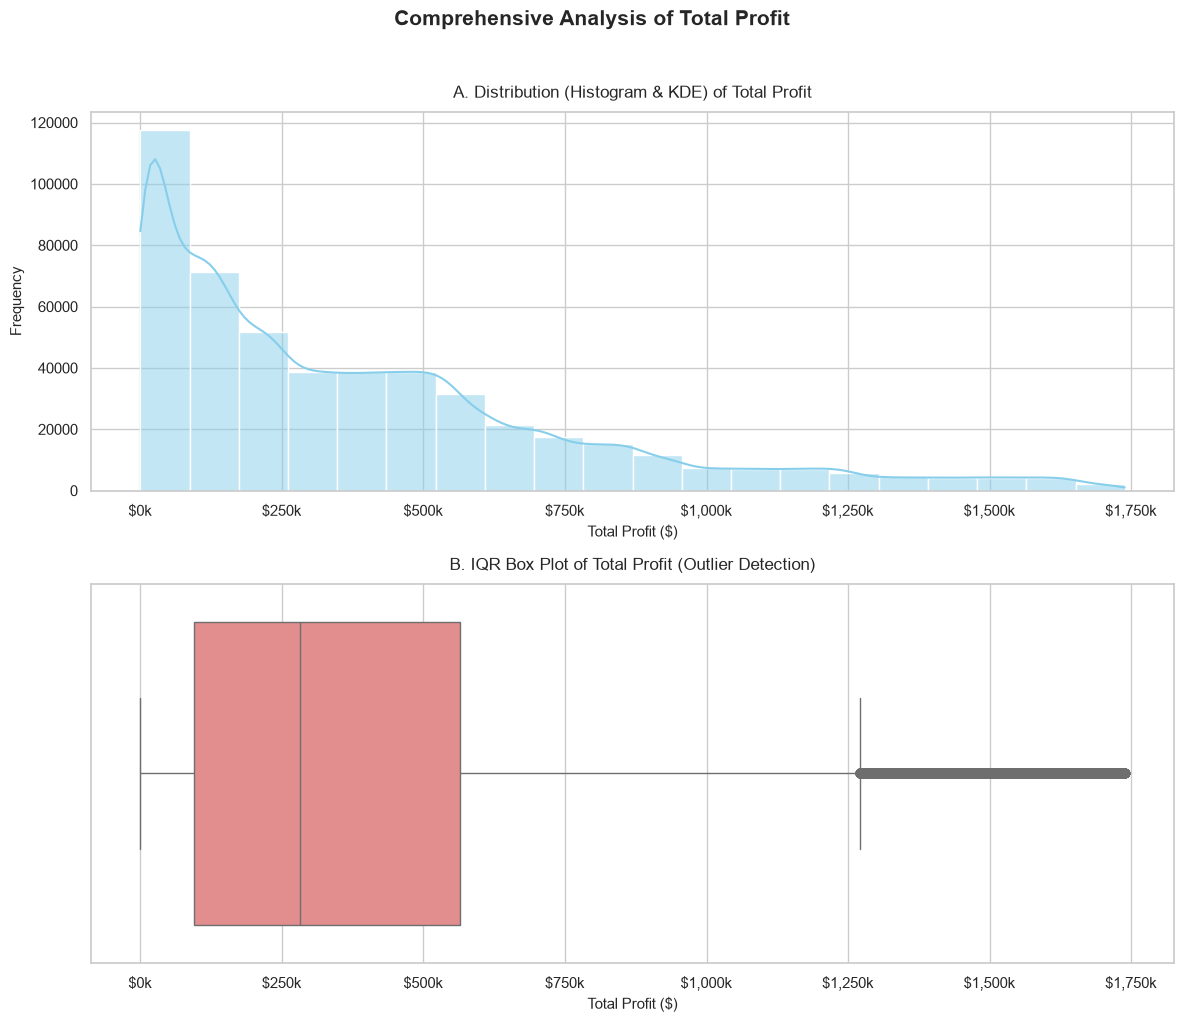

In [19]:
# Set a clean visual theme for the plots
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------
# 1. Numerical Column Analysis: 'Total Profit' (Dual Visualization)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
# Plot A: Histogram (Shows Shape and Density)
sns.histplot(data=df_cleaned, x='Total Profit', kde=True, color='skyblue', bins=20, ax=axes[0])
axes[0].set_title('A. Distribution (Histogram & KDE) of Total Profit', fontsize=12, pad=10)
axes[0].set_xlabel('Total Profit ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000):,}k"))

# Plot B: Box Plot (Shows IQR, Bounds, and Outliers)
sns.boxplot(data=df_cleaned, x='Total Profit', color='lightcoral', ax=axes[1])
axes[1].set_title('B. IQR Box Plot of Total Profit (Outlier Detection)', fontsize=12, pad=10)
axes[1].set_xlabel('Total Profit ($)', fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000):,}k"))

plt.suptitle('Comprehensive Analysis of Total Profit', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


We analyzed **Total Profit** using a dual-plot approach—a histogram stacked atop a box plot—because they complement each other perfectly to reveal both the distribution shape and the underlying statistics.

**Distribution Shape & Skewness**: The histogram reveals that most transactions are concentrated at lower profit levels (below $200,000), creating a highly right-skewed distribution with a long tail stretching toward $1.5M. This indicates that while the majority of our volume is modest, a small subset of high-value transactions drives the tail.

**Statistical Bounds & Outliers**: The box plot defines the mathematical IQR limits for this data. The "box" captures the middle 50% of our transactions, while the individual dots to the right confirm the high-value outliers.

**Whisker Behavior**: Notably, the left whisker terminates near $0 rather than our calculated theoretical bound of -$609,625.77. This confirms that our dataset contains no loss-making (negative-profit) transactions

##### 3.1.2 categorical column analysis
- Pick one categorical column from the dataset.
- Create a bar chart showing how often each category appears.
- Write one observation about which category is most common and which is least common.

In [36]:
import math
item_type_counts = df_cleaned['Item Type'].value_counts()

print("--- Frequency of Each Item Type ---")
print(item_type_counts)
print("\n")
max_val = item_type_counts.max()
min_val = item_type_counts.min()

max_item = item_type_counts.idxmax()
min_item = item_type_counts.idxmin()

# Print the results
print(f"Maximum Frequency: {max_item} ({max_val} transactions)")
print(f"Minimum Frequency: {min_item} ({min_val} transactions)")
print(f"Absolute Difference: {max_val - min_val} transactions")

lower_bound = math.floor(max_val / 1000) * 1000
upper_bound = math.ceil(min_val / 1000) * 1000

--- Frequency of Each Item Type ---
Item Type
Personal Care      41789
Cosmetics          41717
Snacks             41706
Clothes            41689
Fruits             41684
Meat               41673
Baby Food          41657
Vegetables         41655
Cereal             41619
Household          41617
Beverages          41616
Office Supplies    41578
Name: count, dtype: int64


Maximum Frequency: Personal Care (41789 transactions)
Minimum Frequency: Office Supplies (41578 transactions)
Absolute Difference: 211 transactions


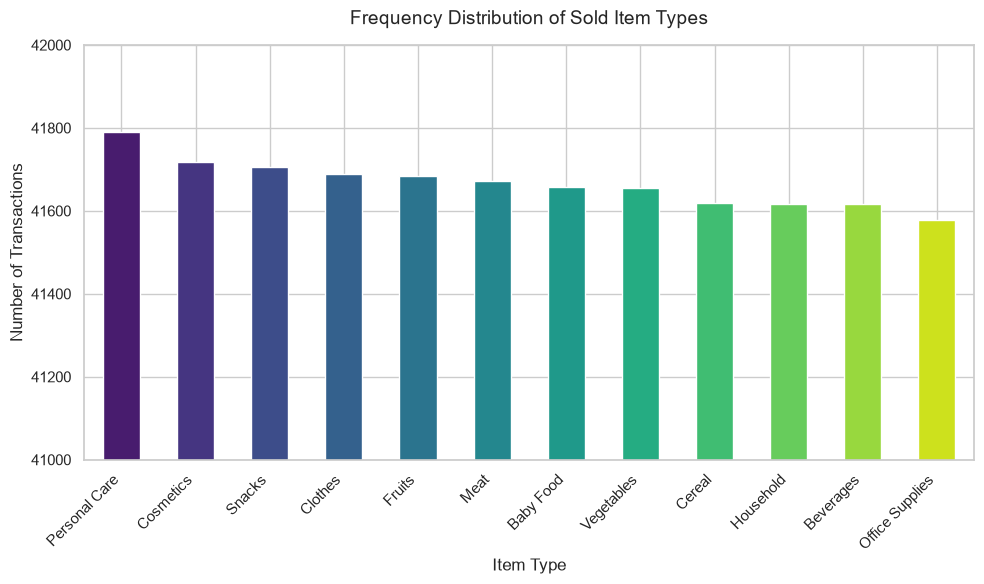

In [37]:
# Create a simple bar plot using the sorted counts

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
item_type_counts.plot(kind='bar', color=sns.color_palette('viridis', len(item_type_counts)))
plt.title('Frequency Distribution of Sold Item Types', fontsize=14, pad=15)
plt.xlabel('Item Type', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.ylim(lower_bound, upper_bound)

plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

#### 3.2 Relationship Between Two Columns


#### 3.3 Looking at Multiple Columns Together
-

#### 3.4 Summary of Findings
-